In [8]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

raw_df = pd.read_csv('../data/household_power_consumption.csv')
raw_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [9]:
# Keep the complete dataset and create a timestamp for every observation.
df = raw_df.copy()
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce'
)
df = df.dropna(subset=['Datetime']).sort_values('Datetime')

measurement_columns = [
    column for column in df.columns if column not in ['Date', 'Time', 'Datetime']
]
df[measurement_columns] = df[measurement_columns].apply(
    pd.to_numeric, errors='coerce'
)

print('Full data shape:', df.shape)
print('Date range:', df['Datetime'].min(), 'to', df['Datetime'].max())
df.head()

Full data shape: (1048575, 10)
Date range: 2006-12-16 17:24:00 to 2008-12-13 21:38:00


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [10]:
# Add absent minute timestamps and interpolate gaps from their adjacent observations.
minute_index = pd.date_range(
    start=df['Datetime'].min(), end=df['Datetime'].max(), freq='min'
)
df_minute = (
    df.set_index('Datetime')[measurement_columns]
    .reindex(minute_index)
    .rename_axis('Datetime')
)
missing_before = df_minute[measurement_columns].isna().sum()
df_minute[measurement_columns] = df_minute[measurement_columns].interpolate(
    method='time', limit_area='inside'
)
df_minute = df_minute.reset_index()
df_minute['Date'] = df_minute['Datetime'].dt.strftime('%d/%m/%Y')
df_minute['Time'] = df_minute['Datetime'].dt.strftime('%H:%M:%S')

pd.DataFrame({
    'missing_before': missing_before,
    'missing_after': df_minute[measurement_columns].isna().sum(),
})

,missing_before,missing_after
Global_active_power,4069,0
Global_reactive_power,4069,0
Voltage,4069,0
Global_intensity,4069,0
Sub_metering_1,4069,0
Sub_metering_2,4069,0
Sub_metering_3,4069,0


In [11]:
# Increment this zero-based value to inspect another seven-day period.
week_number = 0

first_week_start = df_minute['Datetime'].min().normalize() + pd.Timedelta(days=1)
week_start = first_week_start + pd.Timedelta(weeks=week_number)
week_end = week_start + pd.Timedelta(days=7)
weekly_data = df_minute.loc[
    df_minute['Datetime'].between(week_start, week_end, inclusive='left')
].copy()

if weekly_data.empty:
    raise ValueError(f'week_number={week_number} is outside the available data range.')

def plot_week(column, ylabel, color):
    fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharey=True)
    for day_number, axis in enumerate(axes):
        day_start = week_start + pd.Timedelta(days=day_number)
        day_end = day_start + pd.Timedelta(days=1)
        daily_data = weekly_data.loc[
            weekly_data['Datetime'].between(day_start, day_end, inclusive='left')
        ]
        axis.plot(daily_data['Datetime'], daily_data[column], color=color, linewidth=0.8)
        axis.set_title(day_start.strftime('%A, %d %B %Y'), loc='left')
        axis.set_ylabel(ylabel)
        axis.set_xlim(day_start, day_end)
        axis.xaxis.set_major_locator(mdates.HourLocator(interval=4))
        axis.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axis.grid(alpha=0.25)
    axes[-1].set_xlabel('Time of day')
    fig.suptitle(f'{column} — week {week_number} ({week_start:%Y-%m-%d} to {week_end - pd.Timedelta(days=1):%Y-%m-%d})')
    fig.tight_layout()
    plt.show()

print(f'Displaying week {week_number}: {week_start:%Y-%m-%d} through {week_end - pd.Timedelta(days=1):%Y-%m-%d}')
weekly_data.head()

Displaying week 0: 2006-12-17 through 2006-12-23


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Date,Time
396,2006-12-17 00:00:00,1.044,0.152,242.73,4.4,0.0,2.0,0.0,17/12/2006,00:00:00
397,2006-12-17 00:01:00,1.520,0.220,242.20,7.4,0.0,1.0,0.0,17/12/2006,00:01:00
398,2006-12-17 00:02:00,3.038,0.194,240.14,12.6,0.0,2.0,0.0,17/12/2006,00:02:00
399,2006-12-17 00:03:00,2.974,0.194,239.97,12.4,0.0,1.0,0.0,17/12/2006,00:03:00
400,2006-12-17 00:04:00,2.846,0.198,240.39,11.8,0.0,2.0,0.0,17/12/2006,00:04:00


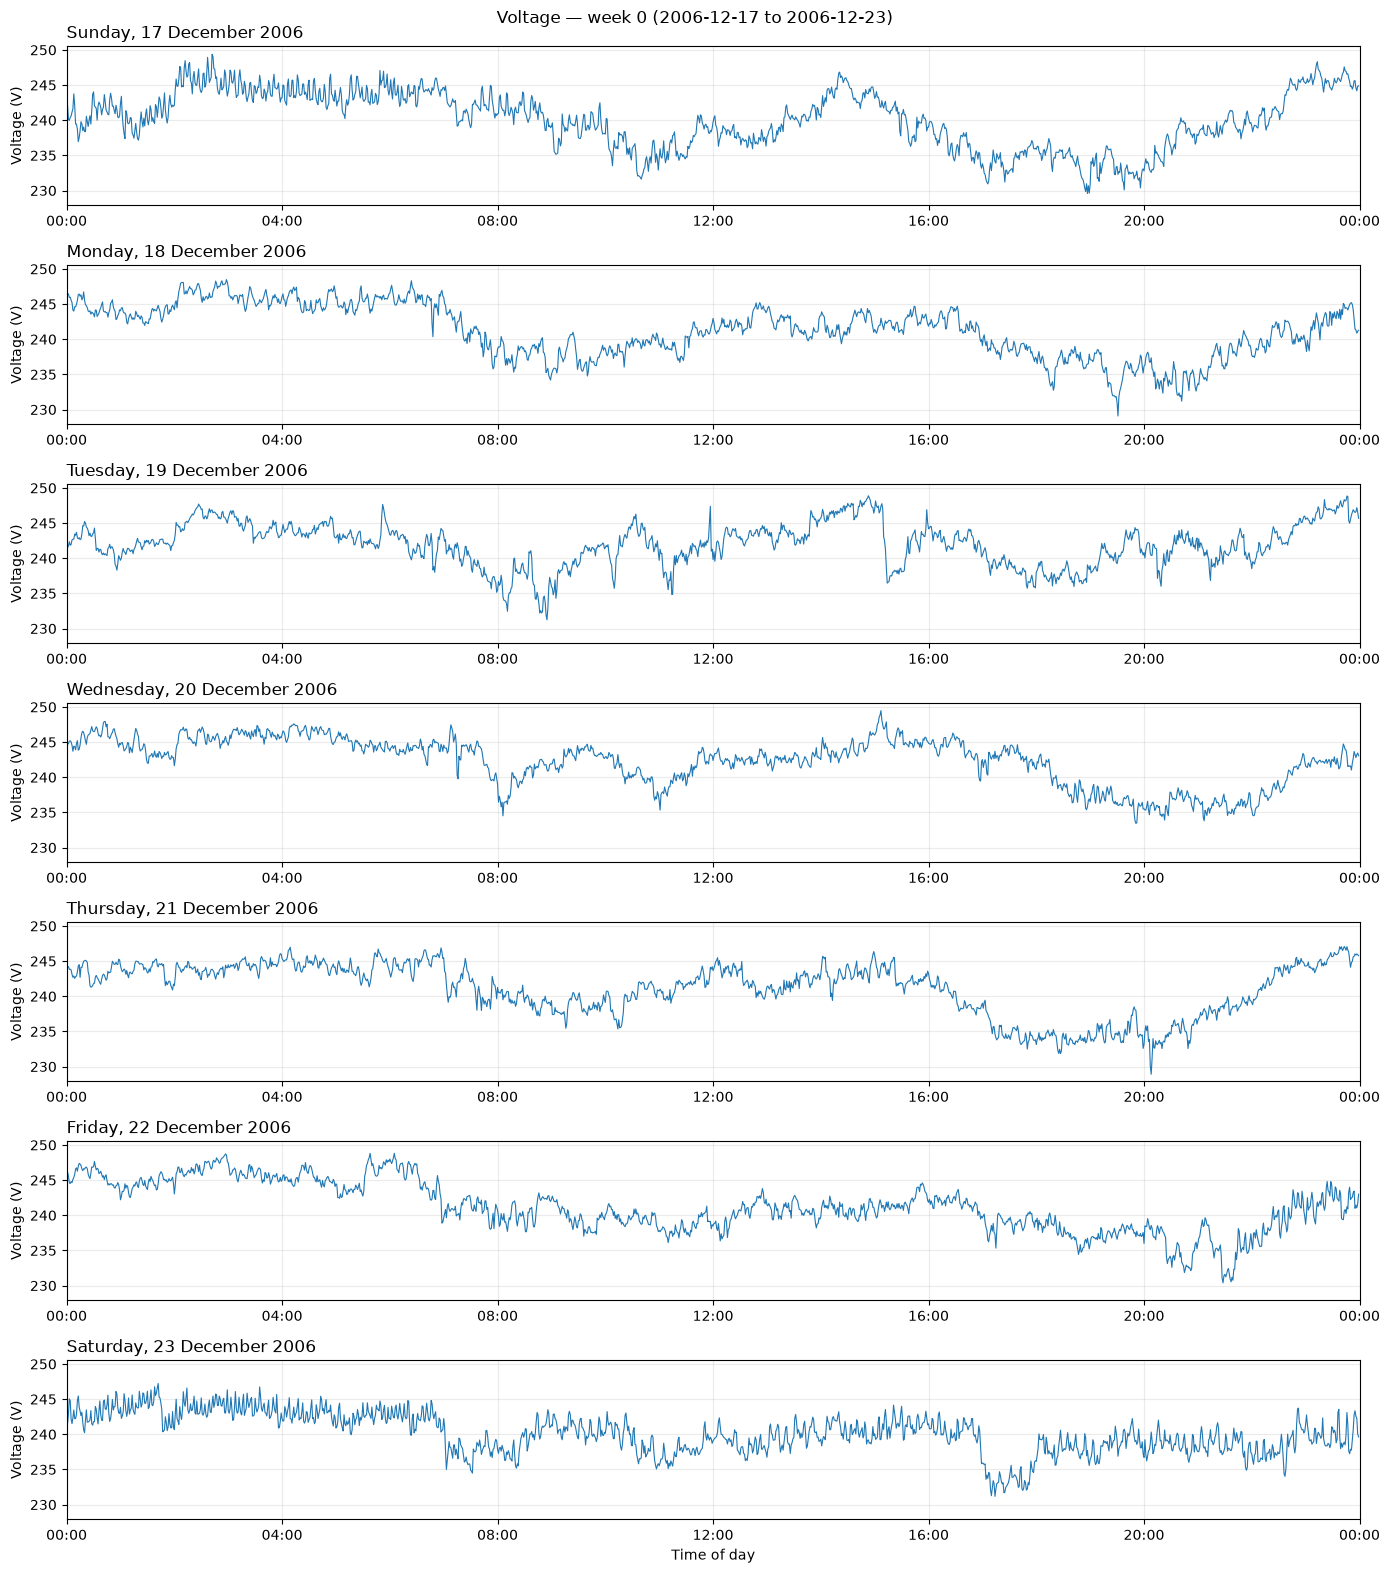

In [12]:
plot_week('Voltage', 'Voltage (V)', 'tab:blue')

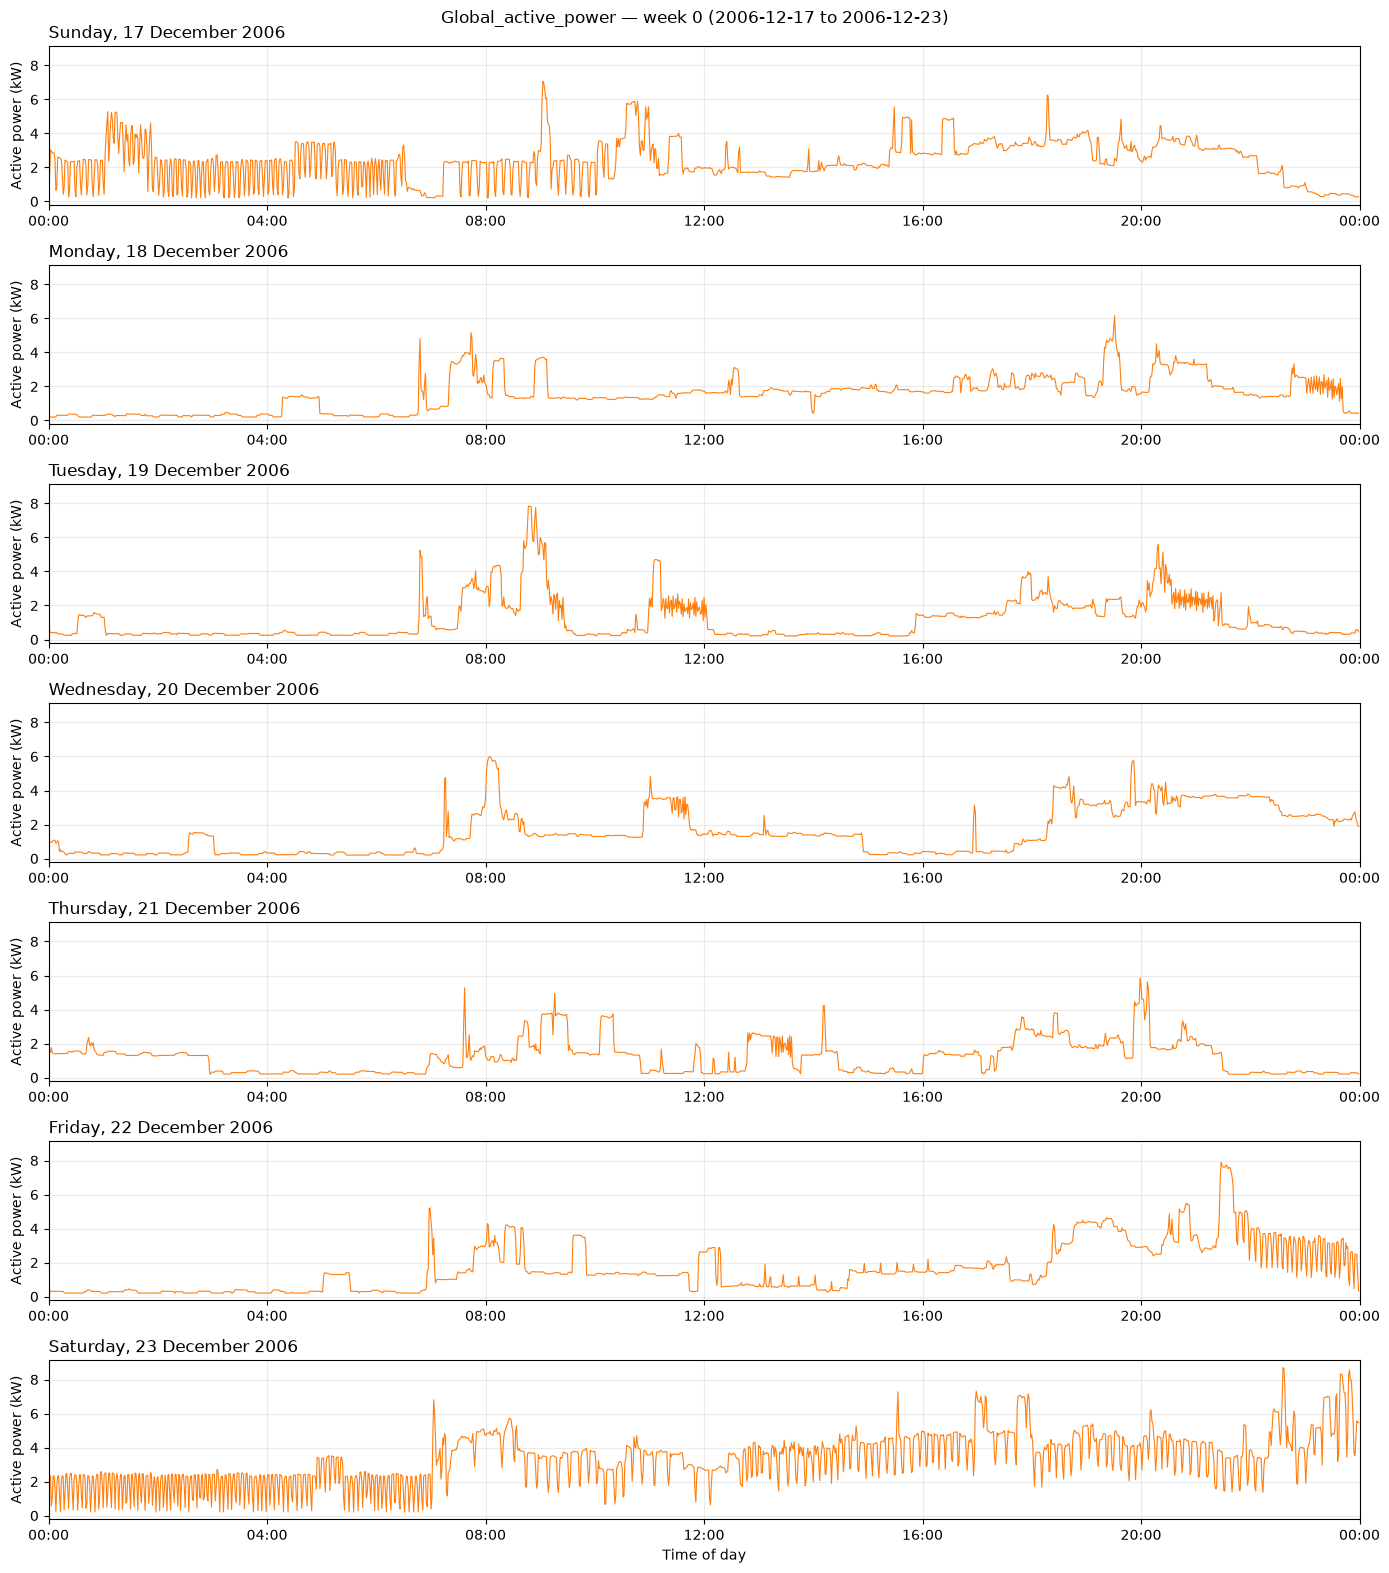

In [13]:
plot_week('Global_active_power', 'Active power (kW)', 'tab:orange')

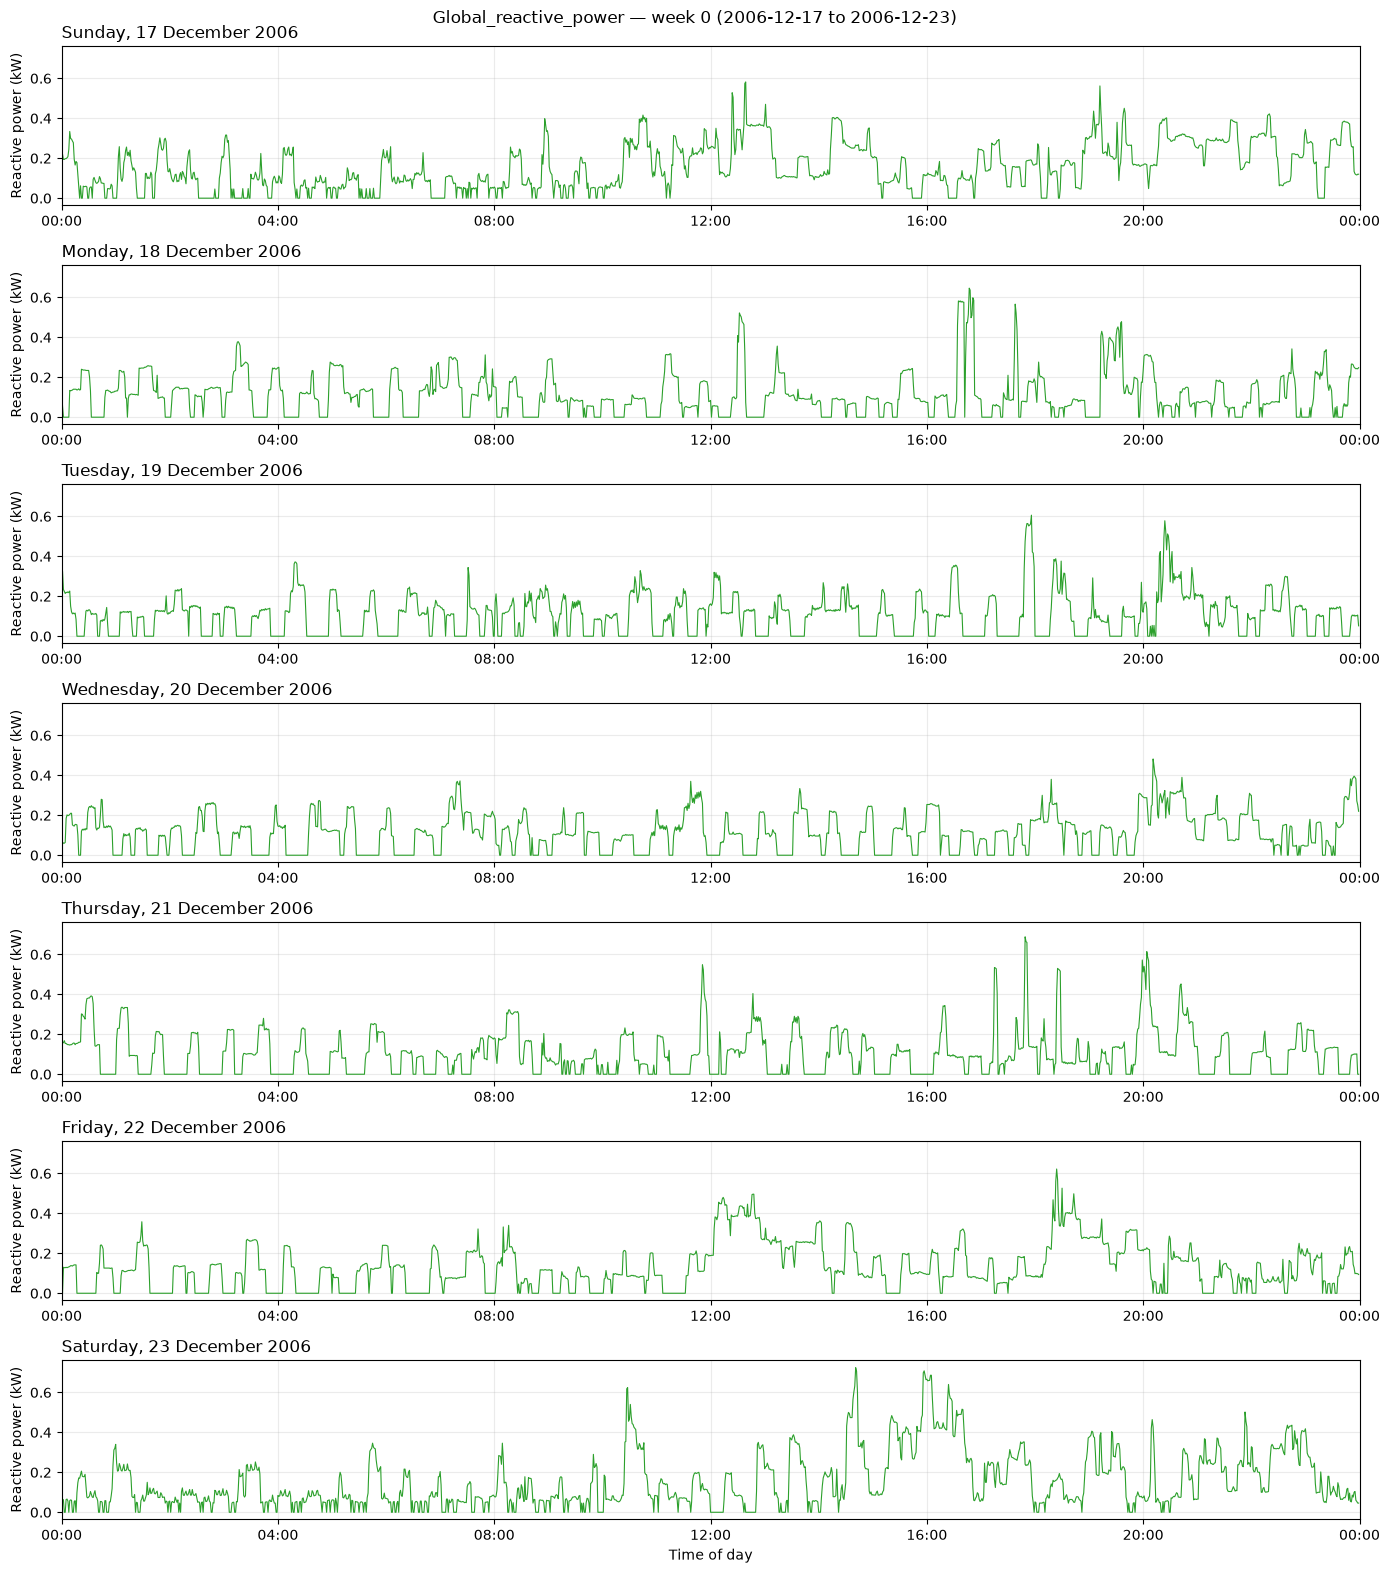

In [14]:
plot_week('Global_reactive_power', 'Reactive power (kW)', 'tab:green')

## Synthetic three-phase loads for seven buildings

This section preserves the analysis above and independently prepares active and reactive power for a synthetic three-phase, seven-building dataset.

In [15]:
from pathlib import Path

# Inspected schema: Date + Time form the timestamp; source samples are one minute apart.
timestamp_column = 'Datetime'
active_power_column = 'Global_active_power'
reactive_power_column = 'Global_reactive_power'
power_columns = [active_power_column, reactive_power_column]

source_loads = raw_df.copy()
source_loads[timestamp_column] = pd.to_datetime(
    source_loads['Date'] + ' ' + source_loads['Time'],
    dayfirst=True, errors='coerce',
)
source_loads[power_columns] = source_loads[power_columns].apply(
    pd.to_numeric, errors='coerce'
)
invalid_timestamp_rows = int(source_loads[timestamp_column].isna().sum())
source_loads = source_loads.dropna(subset=[timestamp_column]).sort_values(timestamp_column)
duplicate_timestamps_removed = int(source_loads[timestamp_column].duplicated().sum())
source_loads = source_loads.drop_duplicates(timestamp_column, keep='first')
earliest_valid_datetime = source_loads[timestamp_column].min()
observed_intervals = source_loads[timestamp_column].diff().dropna()
sampling_interval = observed_intervals.mode().iat[0]
continuous_index = pd.date_range(
    source_loads[timestamp_column].min(), source_loads[timestamp_column].max(), freq='min'
)
prepared_power = source_loads.set_index(timestamp_column)[power_columns].reindex(continuous_index)
prepared_power.index.name = timestamp_column
timestamps_filled = int(len(continuous_index) - len(source_loads))
missing_power_before = prepared_power[power_columns].isna().sum()
prepared_power[power_columns] = prepared_power[power_columns].interpolate(
    method='time', limit_area='inside'
)
missing_power_after = prepared_power[power_columns].isna().sum()
power_values_filled = missing_power_before - missing_power_after

# Edge values without observations on both sides remain missing; their days are excluded below.
preprocessing_report = {
    'timestamp_source': 'Date + Time -> Datetime',
    'active_power_source': active_power_column,
    'reactive_power_source': reactive_power_column,
    'sampling_interval': sampling_interval,
    'invalid_timestamp_rows_removed': invalid_timestamp_rows,
    'duplicate_timestamps_removed': duplicate_timestamps_removed,
    'missing_timestamps_inserted': timestamps_filled,
    'active_power_values_filled': int(power_values_filled[active_power_column]),
    'reactive_power_values_filled': int(power_values_filled[reactive_power_column]),
    'unfilled_active_edge_values': int(missing_power_after[active_power_column]),
    'unfilled_reactive_edge_values': int(missing_power_after[reactive_power_column]),
}
preprocessing_report

{'timestamp_source': 'Date + Time -> Datetime',
 'active_power_source': 'Global_active_power',
 'reactive_power_source': 'Global_reactive_power',
 'sampling_interval': Timedelta('0 days 00:01:00'),
 'invalid_timestamp_rows_removed': 0,
 'duplicate_timestamps_removed': 0,
 'missing_timestamps_inserted': 0,
 'active_power_values_filled': 4069,
 'reactive_power_values_filled': 4069,
 'unfilled_active_edge_values': 0,
 'unfilled_reactive_edge_values': 0}

In [16]:
# Keep only complete calendar days containing exactly 1,440 valid one-minute samples.
first_complete_day = prepared_power.index.min().ceil('D')
last_complete_day_end = prepared_power.index.max().floor('D')
complete_day_window = prepared_power.loc[
    (prepared_power.index >= first_complete_day)
    & (prepared_power.index < last_complete_day_end)
]
daily_chunks = [
    day_frame
    for _, day_frame in complete_day_window.groupby(complete_day_window.index.normalize(), sort=True)
    if len(day_frame) == 1_440 and not day_frame[power_columns].isna().any().any()
]
complete_days_discarded_for_missing_power = (
    complete_day_window.index.normalize().nunique() - len(daily_chunks)
)
usable_day_count = (len(daily_chunks) // 3) * 3
trailing_daily_chunks_discarded = len(daily_chunks) - usable_day_count

# Three consecutive source days become aligned Phase A/B/C profiles by minute of day.
phase_groups = []
for group_start in range(0, usable_day_count, 3):
    phase_a, phase_b, phase_c = daily_chunks[group_start:group_start + 3]
    phase_groups.append(pd.DataFrame({
        'Phase_A_P_kW': phase_a[active_power_column].to_numpy(),
        'Phase_A_Q_kvar': phase_a[reactive_power_column].to_numpy(),
        'Phase_B_P_kW': phase_b[active_power_column].to_numpy(),
        'Phase_B_Q_kvar': phase_b[reactive_power_column].to_numpy(),
        'Phase_C_P_kW': phase_c[active_power_column].to_numpy(),
        'Phase_C_Q_kvar': phase_c[reactive_power_column].to_numpy(),
    }))
three_phase_profile = pd.concat(phase_groups, ignore_index=True)
print('Complete daily chunks:', len(daily_chunks))
print('Complete days excluded for unfilled power:', complete_days_discarded_for_missing_power)
print('Daily chunks discarded at the end:', trailing_daily_chunks_discarded)
print('Three-phase profile shape:', three_phase_profile.shape)

Complete daily chunks: 727
Complete days excluded for unfilled power: 0
Daily chunks discarded at the end: 1
Three-phase profile shape: (348480, 6)


In [17]:
# Split consecutive profile rows equally across seven buildings without shuffling.
building_count = 7
rows_per_building = len(three_phase_profile) // building_count
rows_retained = rows_per_building * building_count
trailing_profile_rows_discarded = len(three_phase_profile) - rows_retained
equal_profile = three_phase_profile.iloc[:rows_retained].copy()
building_frames = []
shared_datetime = pd.date_range(earliest_valid_datetime, periods=rows_per_building, freq='min')
for building_id in range(1, building_count + 1):
    start = (building_id - 1) * rows_per_building
    stop = building_id * rows_per_building
    building = equal_profile.iloc[start:stop].copy()
    building.insert(0, 'Datetime', shared_datetime)
    building.insert(0, 'Building_ID', building_id)
    building_frames.append(building)
synthetic_building_loads = pd.concat(building_frames, ignore_index=True)
synthetic_building_loads = synthetic_building_loads.sort_values(
    ['Building_ID', 'Datetime'], ignore_index=True
)
print('Trailing three-phase rows discarded for equal division:', trailing_profile_rows_discarded)

Trailing three-phase rows discarded for equal division: 6


In [18]:
phase_power_columns = [
    'Phase_A_P_kW', 'Phase_A_Q_kvar',
    'Phase_B_P_kW', 'Phase_B_Q_kvar',
    'Phase_C_P_kW', 'Phase_C_Q_kvar',
]
building_counts = synthetic_building_loads.groupby('Building_ID', sort=True).size()
continuous_by_building = synthetic_building_loads.groupby('Building_ID', sort=True)[
    'Datetime'
].apply(lambda values: values.diff().dropna().eq(pd.Timedelta(minutes=1)).all())
expected_order = synthetic_building_loads.sort_values(
    ['Building_ID', 'Datetime'], ignore_index=True
)
# The source CSV has no unit metadata; requested P_kW/Q_kvar names use no scale conversion.
unit_metadata = {column: ('kW' if '_P_' in column else 'kvar') for column in phase_power_columns}
validation_results = {
    'exactly_seven_buildings': synthetic_building_loads['Building_ID'].nunique() == 7,
    'equal_rows_per_building': building_counts.nunique() == 1,
    'continuous_one_minute_per_building': bool(continuous_by_building.all()),
    'all_phase_power_columns_exist': set(phase_power_columns).issubset(synthetic_building_loads),
    'unique_building_datetime_pairs': not synthetic_building_loads.duplicated(
        ['Building_ID', 'Datetime']
    ).any(),
    'no_missing_phase_power_values': not synthetic_building_loads[phase_power_columns].isna().any().any(),
    'expected_units_in_column_schema': set(unit_metadata.values()) == {'kW', 'kvar'},
    'ordered_by_building_then_datetime': synthetic_building_loads.equals(expected_order),
}
assert all(validation_results.values()), validation_results
output_path = Path('../data/synthetic_7_building_3_phase_loads.csv')
synthetic_building_loads.to_csv(output_path, index=False)
print('Shape:', synthetic_building_loads.shape)
print('Columns:', synthetic_building_loads.columns.tolist())
print('Building counts:')
display(building_counts.rename('rows'))
print('Shared datetime range:', synthetic_building_loads['Datetime'].min(), 'to', synthetic_building_loads['Datetime'].max())
print('Units:', unit_metadata)
print('Validation results:', validation_results)
print('Saved:', output_path.resolve())
synthetic_building_loads.head(10)

Shape: (348474, 8)
Columns: ['Building_ID', 'Datetime', 'Phase_A_P_kW', 'Phase_A_Q_kvar', 'Phase_B_P_kW', 'Phase_B_Q_kvar', 'Phase_C_P_kW', 'Phase_C_Q_kvar']
Building counts:


Building_ID
1    49782
2    49782
3    49782
4    49782
5    49782
6    49782
7    49782
Name: rows, dtype: int64

Shared datetime range: 2006-12-16 17:24:00 to 2007-01-20 07:05:00
Units: {'Phase_A_P_kW': 'kW', 'Phase_A_Q_kvar': 'kvar', 'Phase_B_P_kW': 'kW', 'Phase_B_Q_kvar': 'kvar', 'Phase_C_P_kW': 'kW', 'Phase_C_Q_kvar': 'kvar'}
Validation results: {'exactly_seven_buildings': True, 'equal_rows_per_building': True, 'continuous_one_minute_per_building': True, 'all_phase_power_columns_exist': True, 'unique_building_datetime_pairs': True, 'no_missing_phase_power_values': True, 'expected_units_in_column_schema': True, 'ordered_by_building_then_datetime': True}
Saved: C:\Users\d8tns\OneDrive\Desktop\PSE-summer-2026\DistributionSystems\Maez\data\synthetic_7_building_3_phase_loads.csv


,Building_ID,Datetime,Phase_A_P_kW,Phase_A_Q_kvar,Phase_B_P_kW,Phase_B_Q_kvar,Phase_C_P_kW,Phase_C_Q_kvar
0,1,2006-12-16 17:24:00,1.044,0.152,0.278,0.126,0.414,0.242
1,1,2006-12-16 17:25:00,1.520,0.220,0.238,0.056,0.504,0.326
2,1,2006-12-16 17:26:00,3.038,0.194,0.208,0.000,0.408,0.234
3,1,2006-12-16 17:27:00,2.974,0.194,0.206,0.000,0.416,0.224
4,1,2006-12-16 17:28:00,2.846,0.198,0.206,0.000,0.394,0.214
5,1,2006-12-16 17:29:00,2.848,0.198,0.206,0.000,0.410,0.220
6,1,2006-12-16 17:30:00,2.858,0.202,0.204,0.000,0.390,0.218
7,1,2006-12-16 17:31:00,2.472,0.208,0.204,0.000,0.408,0.222
8,1,2006-12-16 17:32:00,0.658,0.244,0.212,0.000,0.388,0.218
9,1,2006-12-16 17:33:00,0.838,0.334,0.316,0.134,0.406,0.226


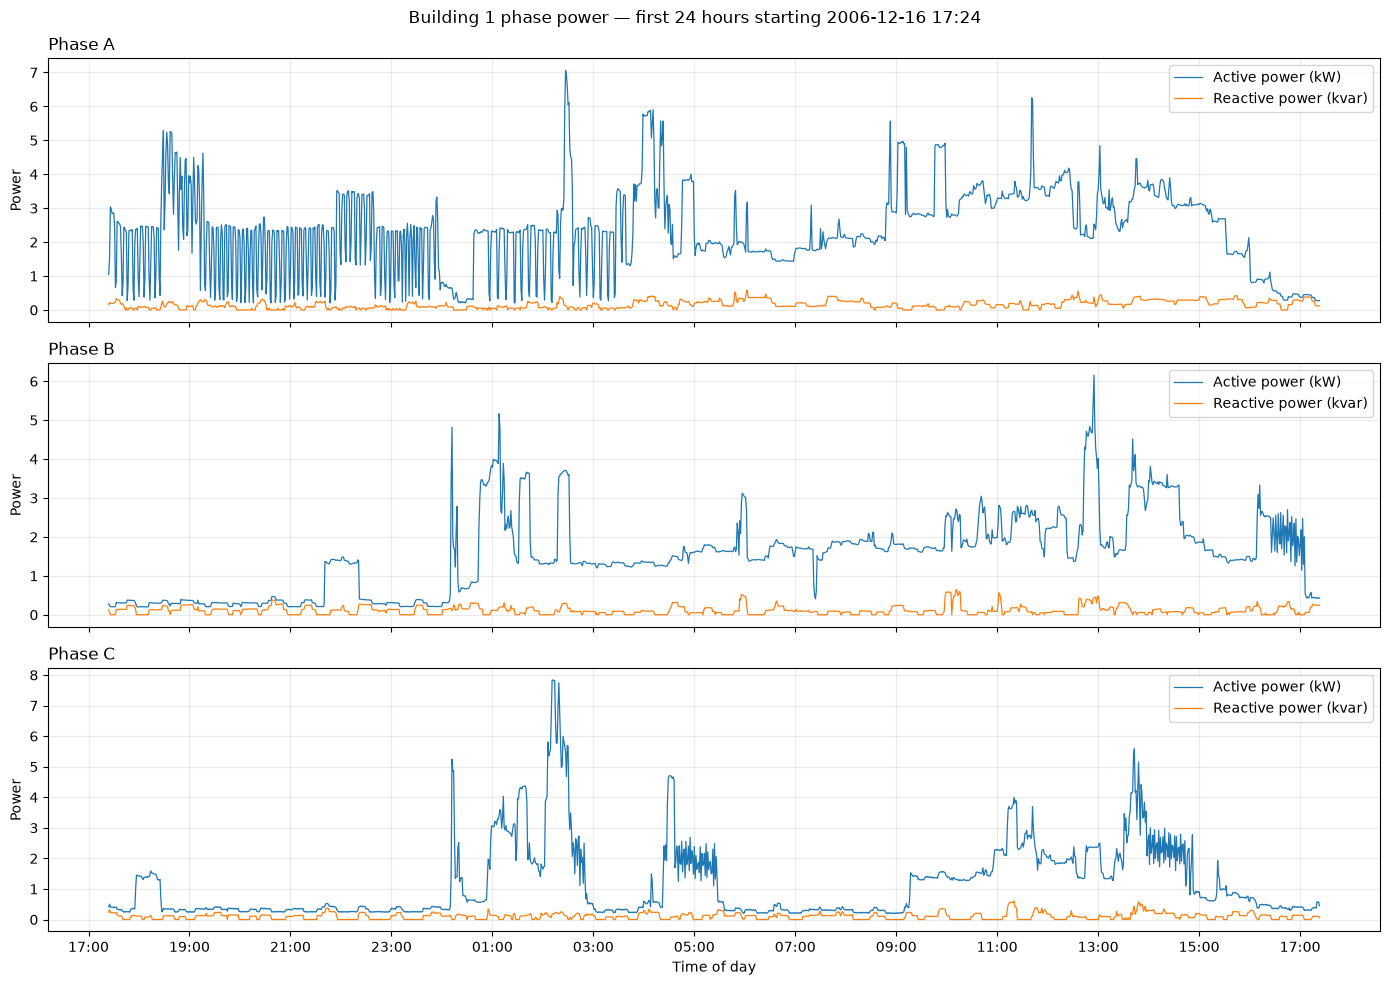

In [19]:
# Compare active and reactive power on each phase during Building 1's first 24 hours.
building_1 = synthetic_building_loads.loc[
    synthetic_building_loads['Building_ID'] == 1
].copy()
first_day_start = building_1['Datetime'].min()
first_day_end = first_day_start + pd.Timedelta(days=1)
building_1_first_day = building_1.loc[
    building_1['Datetime'].between(first_day_start, first_day_end, inclusive='left')
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, phase in zip(axes, ['A', 'B', 'C']):
    axis.plot(
        building_1_first_day['Datetime'],
        building_1_first_day[f'Phase_{phase}_P_kW'],
        label='Active power (kW)', linewidth=0.9,
    )
    axis.plot(
        building_1_first_day['Datetime'],
        building_1_first_day[f'Phase_{phase}_Q_kvar'],
        label='Reactive power (kvar)', linewidth=0.9,
    )
    axis.set_title(f'Phase {phase}', loc='left')
    axis.set_ylabel('Power')
    axis.grid(alpha=0.25)
    axis.legend(loc='upper right')

axes[-1].set_xlabel('Time of day')
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.suptitle(
    f'Building 1 phase power — first 24 hours starting {first_day_start:%Y-%m-%d %H:%M}'
)
fig.tight_layout()
plt.show()